In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(r"C:\Users\solay\Documents\OneDrive\OpenClassrooms\P5\data\QueryResults.csv")

In [3]:
df

,Title,Body,Tags,Id,Score,ViewCount,FavoriteCount,AnswerCount
0,Paging a collection with LINQ,<p>How do you page through a collection in LIN...,<linq><.net-3.5>,66,89,6427,NaN,4
1,How do I add existing comments to RDoc in Ruby?,<p>I want to format my existing comments as 'R...,<ruby><rdoc>,72,48,2232,NaN,2
2,Getting Subclipse in Aptana to work with the n...,<p>The version of <strong>Subclipse (1.2.4)</s...,<eclipse><svn><aptana><subclipse>,79,50,11502,NaN,4
3,SQLStatement.execute() - multiple queries in o...,<p>I've written a database generation script i...,<apache-flex><actionscript-3><air>,80,54,6774,NaN,3
4,Flat file databases,<p>What are the best practices around creating...,<php><sql><database><flat-file>,85,133,70693,NaN,11
...,...,...,...,...,...,...,...,...
49995,Collection initialization syntax in Visual Bas...,<p>I'm trying to determine if there's a way in...,<vb.net><visual-studio-2008><collections><init...,85892,24,7014,NaN,2
49996,Is there a tutorial that teaches common Ruby p...,<p>I'm looking for a Ruby's equivalent of <a h...,<ruby><idioms>,85916,30,1848,NaN,8
49997,XML Notepad 2007 breaks MS Access 2007 Help,<p>I tried scouring the web for help on this i...,<xml><ms-office>,85923,0,961,NaN,2
49998,Why do I need a flickr api key?,<p>Reading through the Flickr API documentatio...,<flickr>,86163,16,14868,NaN,5


In [4]:
from bs4 import BeautifulSoup

def remove_html_tags(text):
    return BeautifulSoup(text, "html.parser").get_text()

df['Body_no_html'] = df['Body'].apply(remove_html_tags)

In [5]:
df_top100 = df.groupby('Tags').size().sort_values(ascending=False).head(100)

In [6]:
#df = df[:100]

In [7]:
df.loc[0,"Body_no_html"]

'How do you page through a collection in LINQ given that you have a startIndex and a count?\n'

In [8]:
import spacy, re
# Load spaCy's English model
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    from spacy.cli import download
    download("en_core_web_sm")
    nlp = spacy.load("en_core_web_sm")
version_pattern = re.compile(r'^\d+(\.\d+)+$')
def clean_text(text):
    doc = nlp(text.lower())
    tokens = [
        token.lemma_
        for token in doc
        if (
            (token.is_alpha or token.text.isalnum())
            and not token.is_stop
            and not token.pos_ == "PRON"
            and not version_pattern.match(token.text)
        )
    ]
    return " ".join(tokens)
df['cleaned_Body'] = df['Body_no_html'].apply(clean_text)

In [9]:
df['cleaned_Body']

0               page collection linq give startindex count
1        want format exist comment rdoc comment view ri...
2        version subclipse currently available aptana a...
3        write database generation script sql want exec...
4        good practice create flat file database struct...
                               ...                        
49995    try determine way visual basic 2008 express ed...
49996    look ruby equivalent code like pythonista idio...
49997    try scour web help issue generic word find rel...
49998    read flickr api documentation keep state requi...
49999    little background display datum set 288 row 8 ...
Name: cleaned_Body, Length: 50000, dtype: object

In [10]:
df['cleaned_Title'] = df['Title'].apply(clean_text)

In [11]:
df['cleaned_Title']

0                                     page collection linq
1                              add exist comment rdoc ruby
2         get subclipse aptana work new release subversion
3                                 multiple query statement
4                                       flat file database
                               ...                        
49995    collection initialization syntax visual basic ...
49996    tutorial teach common ruby programming idiom e...
49997           xml notepad 2007 break ms access 2007 help
49998                                  need flickr api key
49999    improve performance richface scrollabledatatab...
Name: cleaned_Title, Length: 50000, dtype: object

In [12]:
df

,Title,Body,Tags,Id,Score,ViewCount,FavoriteCount,AnswerCount,Body_no_html,cleaned_Body,cleaned_Title
0,Paging a collection with LINQ,<p>How do you page through a collection in LIN...,<linq><.net-3.5>,66,89,6427,NaN,4,How do you page through a collection in LINQ g...,page collection linq give startindex count,page collection linq
1,How do I add existing comments to RDoc in Ruby?,<p>I want to format my existing comments as 'R...,<ruby><rdoc>,72,48,2232,NaN,2,I want to format my existing comments as 'RDoc...,want format exist comment rdoc comment view ri...,add exist comment rdoc ruby
2,Getting Subclipse in Aptana to work with the n...,<p>The version of <strong>Subclipse (1.2.4)</s...,<eclipse><svn><aptana><subclipse>,79,50,11502,NaN,4,The version of Subclipse (1.2.4) currently ava...,version subclipse currently available aptana a...,get subclipse aptana work new release subversion
3,SQLStatement.execute() - multiple queries in o...,<p>I've written a database generation script i...,<apache-flex><actionscript-3><air>,80,54,6774,NaN,3,I've written a database generation script in S...,write database generation script sql want exec...,multiple query statement
4,Flat file databases,<p>What are the best practices around creating...,<php><sql><database><flat-file>,85,133,70693,NaN,11,What are the best practices around creating fl...,good practice create flat file database struct...,flat file database
...,...,...,...,...,...,...,...,...,...,...,...
49995,Collection initialization syntax in Visual Bas...,<p>I'm trying to determine if there's a way in...,<vb.net><visual-studio-2008><collections><init...,85892,24,7014,NaN,2,I'm trying to determine if there's a way in Vi...,try determine way visual basic 2008 express ed...,collection initialization syntax visual basic ...
49996,Is there a tutorial that teaches common Ruby p...,<p>I'm looking for a Ruby's equivalent of <a h...,<ruby><idioms>,85916,30,1848,NaN,8,I'm looking for a Ruby's equivalent of Code Li...,look ruby equivalent code like pythonista idio...,tutorial teach common ruby programming idiom e...
49997,XML Notepad 2007 breaks MS Access 2007 Help,<p>I tried scouring the web for help on this i...,<xml><ms-office>,85923,0,961,NaN,2,I tried scouring the web for help on this issu...,try scour web help issue generic word find rel...,xml notepad 2007 break ms access 2007 help
49998,Why do I need a flickr api key?,<p>Reading through the Flickr API documentatio...,<flickr>,86163,16,14868,NaN,5,Reading through the Flickr API documentation i...,read flickr api documentation keep state requi...,need flickr api key


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

# Séparation en train/test (80% train, 20% test)
body_train, body_test = train_test_split(df['cleaned_Body'], test_size=0.2, random_state=42)

# Approche 1 : fit et transform sur "Body" Train, transform sur "Body" Test
vectorizer_body = CountVectorizer()
X_train_body = vectorizer_body.fit_transform(body_train)
X_test_body = vectorizer_body.transform(body_test)

# Approche 2 : fit et transform sur "Title" Train, transform sur "Title" Test
title_train = df.loc[body_train.index, 'Title']
title_test = df.loc[body_test.index, 'Title']
vectorizer_title = CountVectorizer()
X_train_title = vectorizer_title.fit_transform(title_train)
X_test_title = vectorizer_title.transform(title_test)

# Approche 3 : fit sur "Title" Train, transform sur "Title" + "Body" Test
title_body_train = title_train
title_body_test = title_test + " " + body_test
vectorizer_title2 = CountVectorizer()
X_train_title2 = vectorizer_title2.fit_transform(title_body_train)
X_test_title2 = vectorizer_title2.transform(title_body_test)

# Approche 4 : fit sur "Body" Train, transform sur "Title" + "Body" Test
title_body_test2 = title_test + " " + body_test
X_test_body2 = vectorizer_body.transform(title_body_test2)

,Title,Body,Tags,Id,Score,ViewCount,FavoriteCount,AnswerCount,Body_no_html,cleaned_Body,cleaned_Title
0,Paging a collection with LINQ,<p>How do you page through a collection in LIN...,<linq><.net-3.5>,66,89,6427,NaN,4,How do you page through a collection in LINQ g...,page collection linq give startindex count,page collection linq
1,How do I add existing comments to RDoc in Ruby?,<p>I want to format my existing comments as 'R...,<ruby><rdoc>,72,48,2232,NaN,2,I want to format my existing comments as 'RDoc...,want format exist comment rdoc comment view ri...,add exist comment rdoc ruby
2,Getting Subclipse in Aptana to work with the n...,<p>The version of <strong>Subclipse (1.2.4)</s...,<eclipse><svn><aptana><subclipse>,79,50,11502,NaN,4,The version of Subclipse (1.2.4) currently ava...,version subclipse currently available aptana a...,get subclipse aptana work new release subversion
3,SQLStatement.execute() - multiple queries in o...,<p>I've written a database generation script i...,<apache-flex><actionscript-3><air>,80,54,6774,NaN,3,I've written a database generation script in S...,write database generation script sql want exec...,multiple query statement
4,Flat file databases,<p>What are the best practices around creating...,<php><sql><database><flat-file>,85,133,70693,NaN,11,What are the best practices around creating fl...,good practice create flat file database struct...,flat file database


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Title          50000 non-null  object 
 1   Body           50000 non-null  object 
 2   Tags           50000 non-null  object 
 3   Id             50000 non-null  int64  
 4   Score          50000 non-null  int64  
 5   ViewCount      50000 non-null  int64  
 6   FavoriteCount  0 non-null      float64
 7   AnswerCount    50000 non-null  int64  
 8   Body_no_html   50000 non-null  object 
 9   cleaned_Body   50000 non-null  object 
 10  cleaned_Title  50000 non-null  object 
dtypes: float64(1), int64(4), object(6)
memory usage: 4.2+ MB


,Id,Score,ViewCount,FavoriteCount,AnswerCount
count,5.000000e+04,50000.000000,5.000000e+04,0.0,50000.000000
mean,7.395151e+06,16.145260,1.621407e+04,NaN,3.029920
std,4.153876e+06,154.968325,1.049073e+05,NaN,4.913556
min,1.400000e+01,-28.000000,2.100000e+01,NaN,0.000000
25%,9.568943e+06,0.000000,4.820000e+02,NaN,1.000000
50%,9.654017e+06,1.000000,1.545000e+03,NaN,2.000000
75%,9.739614e+06,5.000000,5.210000e+03,NaN,3.000000
max,1.013562e+07,13078.000000,5.935212e+06,NaN,518.000000


Nombre de valeurs uniques dans 'Tags': 36868
Exemples de tags : ['<linq><.net-3.5>' '<ruby><rdoc>' '<eclipse><svn><aptana><subclipse>'
 '<apache-flex><actionscript-3><air>' '<php><sql><database><flat-file>']


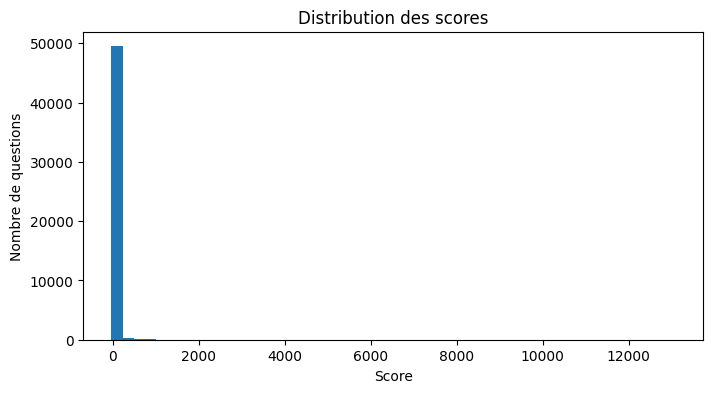

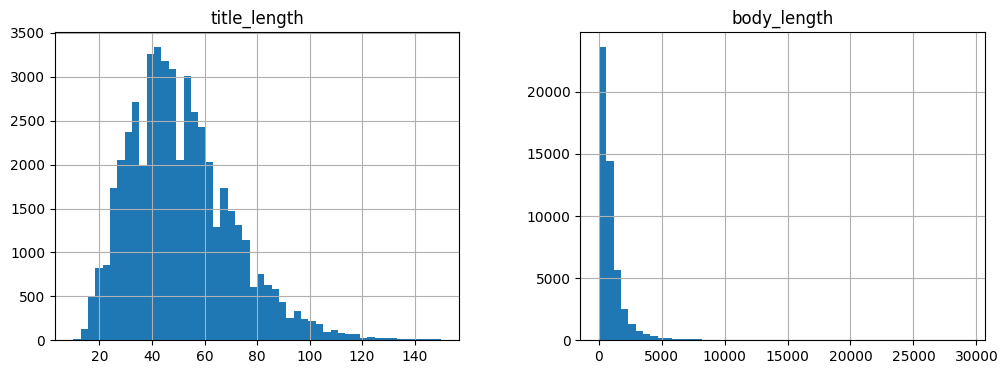

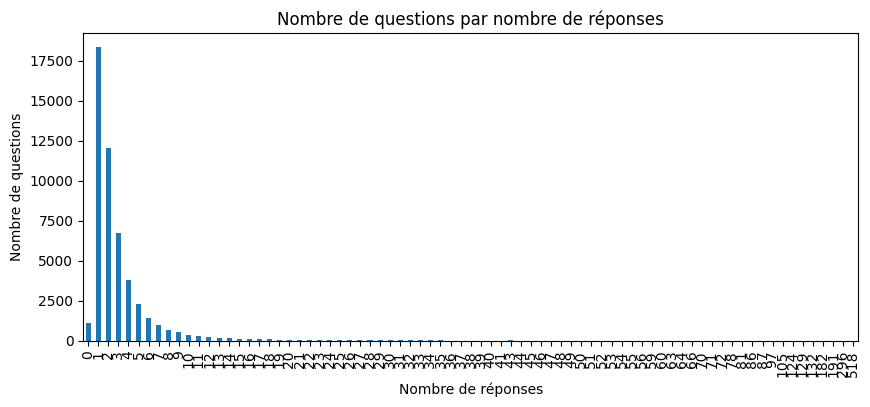

In [14]:
import matplotlib.pyplot as plt


# Analyse exploratoire de base

# Aperçu des premières lignes
display(df.head())

# Informations générales sur le DataFrame
df.info()

# Statistiques descriptives sur les colonnes numériques
display(df.describe())

# Statistiques sur les colonnes textuelles
print("Nombre de valeurs uniques dans 'Tags':", df['Tags'].nunique())
print("Exemples de tags :", df['Tags'].unique()[:5])

# Distribution des scores
df['Score'].hist(bins=50, figsize=(8, 4), grid=False)
plt.title("Distribution des scores")
plt.xlabel("Score")
plt.ylabel("Nombre de questions")
plt.show()

# Longueur des titres et des corps
df['title_length'] = df['Title'].apply(len)
df['body_length'] = df['Body_no_html'].apply(len)
df[['title_length', 'body_length']].hist(bins=50, figsize=(12, 4))
plt.show()

# Nombre de questions par nombre de réponses
df['AnswerCount'].value_counts().sort_index().plot(kind='bar', figsize=(10,4))
plt.title("Nombre de questions par nombre de réponses")
plt.xlabel("Nombre de réponses")
plt.ylabel("Nombre de questions")
plt.show()

In [15]:
df.dtypes

Title             object
Body              object
Tags              object
Id                 int64
Score              int64
ViewCount          int64
FavoriteCount    float64
AnswerCount        int64
Body_no_html      object
cleaned_Body      object
cleaned_Title     object
title_length       int64
body_length        int64
dtype: object

In [16]:
from sklearn.decomposition import LatentDirichletAllocation

# Utilisons le bag-of-words du body pour la LDA
n_topics = 10  # nombre de topics, à ajuster selon le besoin

lda = LatentDirichletAllocation(n_components=n_topics, random_state=42)
lda.fit(X_train_body)

# Affichage des mots les plus importants pour chaque topic
feature_names = vectorizer_body.get_feature_names_out()
for idx, topic in enumerate(lda.components_):
    print(f"Topic {idx+1}: ", " ".join([feature_names[i] for i in topic.argsort()[-10:][::-1]]))

Topic 1:  android int return void include char error code false class
Topic 2:  var page button function work new click want form view
Topic 3:  image div html lib gem td script ruby element css
Topic 4:  public string new 03 void null import private 2012 04
Topic 5:  class test error new project file exception try method property
Topic 6:  file use like way work need code know application find
Topic 7:  table value select query row null column array like datum
Topic 8:  file app server thread service error run client application try
Topic 9:  text color background font self asp li nil border width
Topic 10:  class public return function string code new user file object


In [17]:
from gensim.models import LdaModel
from gensim.corpora import Dictionary

vectorizer_body = CountVectorizer()
X_train_body = vectorizer_body.fit_transform(body_train)
X_test_body = vectorizer_body.transform(body_test)

feature_names = vectorizer_body.get_feature_names_out()
tokenized_docs = [doc.split() for doc in body_train]
gensim_dict = Dictionary(tokenized_docs)
corpus = [gensim_dict.doc2bow(doc) for doc in tokenized_docs]

num_topics = 50  # nombre de topics, à ajuster selon le besoin
lda_model = LdaModel(corpus, num_topics=num_topics, id2word=gensim_dict, passes=10, random_state=42)
for idx, topic in lda_model.print_topics():
    print(f"Topic {idx}: {topic}")
    

Topic 0: 0.101*"datum" + 0.085*"database" + 0.041*"store" + 0.035*"sql" + 0.023*"server" + 0.023*"session" + 0.022*"db" + 0.020*"data" + 0.018*"create" + 0.017*"table"
Topic 28: 0.128*"string" + 0.059*"variable" + 0.049*"print" + 0.037*"output" + 0.034*"character" + 0.025*"loop" + 0.025*"like" + 0.024*"code" + 0.021*"end" + 0.019*"convert"
Topic 23: 0.087*"td" + 0.084*"browser" + 0.066*"ie" + 0.061*"tr" + 0.046*"firefox" + 0.042*"chrome" + 0.020*"safari" + 0.018*"num" + 0.017*"th" + 0.016*"firstname"
Topic 20: 0.096*"category" + 0.074*"random" + 0.053*"pop" + 0.037*"nest" + 0.036*"counter" + 0.025*"macro" + 0.024*"explanation" + 0.020*"onclick" + 0.018*"qt" + 0.018*"strategy"
Topic 1: 0.218*"input" + 0.093*"byte" + 0.049*"customer" + 0.048*"drop" + 0.028*"encode" + 0.027*"chart" + 0.027*"drag" + 0.020*"flow" + 0.019*"encoding" + 0.014*"vendor"
Topic 6: 0.070*"button" + 0.048*"click" + 0.040*"control" + 0.031*"user" + 0.030*"want" + 0.026*"display" + 0.024*"window" + 0.021*"open" + 0.01

In [18]:
import numpy as np
perplexity = lda_model.log_perplexity(corpus)
print(f"Perplexity: {np.exp2(perplexity)}")

Perplexity: 0.00013817992541435817


In [19]:
from gensim.models import CoherenceModel
coherence_model_lda = CoherenceModel(model=lda_model, texts=tokenized_docs, dictionary=gensim_dict, coherence='c_v')
coherence_score = coherence_model_lda.get_coherence()
print(f"Coherence Score: {coherence_score}")

Coherence Score: 0.5108106190827818


In [20]:
# remove XML-illegal/control characters from all object (string) columns then save
illegal_xml_re = re.compile(r'[\x00-\x08\x0B\x0C\x0E-\x1F]')

def _clean_illegal(val):
    return illegal_xml_re.sub('', val) if isinstance(val, str) else val

obj_cols = df.select_dtypes(include=['object']).columns
df[obj_cols] = df[obj_cols].applymap(_clean_illegal)

df.to_excel(r"C:\Users\solay\Documents\OneDrive\OpenClassrooms\P5\cleaned_data.xlsx", index=False)

C:\Users\solay\AppData\Local\Temp\ipykernel_20912\3948567412.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[obj_cols] = df[obj_cols].applymap(_clean_illegal)


In [21]:
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis

# Visualisation des topics avec pyLDAvis
vis_data = gensimvis.prepare(lda_model, corpus, gensim_dict)

In [22]:
vis_data

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
8      0.288410 -0.069195       1        1  12.338763
36     0.088979  0.297012       2        1   5.251411
21     0.218945 -0.162137       3        1   4.261774
32     0.161435  0.176170       4        1   3.846708
2      0.196115  0.044528       5        1   3.484296
48    -0.037071  0.142094       6        1   3.292084
29     0.153788 -0.034865       7        1   3.220099
13     0.183733 -0.071900       8        1   3.126651
15     0.187653 -0.006426       9        1   3.111991
19     0.191542 -0.032388      10        1   3.075996
30     0.220370 -0.037735      11        1   2.967947
6      0.219987 -0.118921      12        1   2.952426
40     0.163685 -0.037493      13        1   2.818326
0      0.147044 -0.106822      14        1   2.779633
45     0.100685  0.092143      15        1   2.383187
31     0.142087  0.053107      16        1   2.2754

In [23]:
# LDA avec CountVectorizer + sklearn, analyse des matrices topics-words et questions-topics

# 1. Matrice topics-mots (Mtopics_words)
Mtopics_words = lda.components_ / lda.components_.sum(axis=1)[:, np.newaxis]  # shape: (n_topics, vocab_size)

# 2. Matrice questions-topics pour le train (Mtrain_quest_topics)
Mtrain_quest_topics = lda.transform(X_train_body)  # shape: (n_train, n_topics)

# 3. Probabilité des mots pour chaque question du train (questions x mots)
Mtrain_quest_words = np.dot(Mtrain_quest_topics, Mtopics_words)  # shape: (n_train, vocab_size)

# 4. Pour le test, prédire la distribution des topics pour chaque question
Mtest_quest_topics = lda.transform(X_test_body)  # shape: (n_test, n_topics)

# 5. Appliquer le seuil de 60% sur les probabilités de topics (pour test)
Mtest_quest_topics[Mtest_quest_topics < 0.6] = 0

# 6. Interprétation : mots-clés par topic
n_top_words = 10
for topic_idx, topic in enumerate(Mtopics_words):
    top_word_indices = topic.argsort()[-n_top_words:][::-1]
    top_words = [feature_names[i] for i in top_word_indices]
    print(f"Topic {topic_idx+1}: {', '.join(top_words)}")

# 7. Visualisation interactive avec pyLDAvis (déjà préparé dans vis_data)
pyLDAvis.display(vis_data)

Topic 1: android, int, return, void, include, char, error, code, false, class
Topic 2: var, page, button, function, work, new, click, want, form, view
Topic 3: image, div, html, lib, gem, td, script, ruby, element, css
Topic 4: public, string, new, 03, void, null, import, private, 2012, 04
Topic 5: class, test, error, new, project, file, exception, try, method, property
Topic 6: file, use, like, way, work, need, code, know, application, find
Topic 7: table, value, select, query, row, null, column, array, like, datum
Topic 8: file, app, server, thread, service, error, run, client, application, try
Topic 9: text, color, background, font, self, asp, li, nil, border, width
Topic 10: class, public, return, function, string, code, new, user, file, object


In [24]:
df.to_excel(r"C:\Users\solay\Documents\OneDrive\OpenClassrooms\P5\cleaned_data.xlsx", index=False)